# Results, Visualisation, and Interpretation

**Author:** Mahdi Dadgar  
**Inputs:** municipality and category benchmark tables produced by Notebook 02

## Purpose of this notebook

This notebook turns the age–sex-adjusted benchmark results into clear figures and concise analytical findings.

The emphasis is not on ranking municipalities as “good” or “bad.” Instead, the goal is to:

- show where actual healthcare costs differ most from age–sex-adjusted expectations
- distinguish relative differences from absolute euro differences
- test how strongly extreme values are associated with municipality size
- identify which care categories contribute most to selected municipality-level patterns
- communicate limitations clearly and avoid causal or efficiency claims that the data cannot support

## Interpretation principle

A Standardised Cost Ratio (SCR) is a **descriptive signal**:

- `SCR > 1.00`: actual costs are above the age–sex-adjusted expectation
- `SCR ≈ 1.00`: actual costs are close to the expectation
- `SCR < 1.00`: actual costs are below the expectation

The analysis does not establish whether healthcare is appropriate, efficient, necessary, or high quality. Those conclusions would require richer clinical, socioeconomic, provider-level, and multi-year data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

current_path = Path.cwd()
PROJECT_ROOT = current_path.parent if current_path.name == "notebooks" else current_path

OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

benchmark_path = OUTPUT_TABLES / "municipality_benchmark.csv"
category_path = OUTPUT_TABLES / "category_breakdown_outliers.csv"
sensitivity_path = OUTPUT_TABLES / "benchmark_sensitivity_summary.csv"

for required_path in [
    benchmark_path,
    category_path,
    sensitivity_path,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required output not found: {required_path.name}. "
            "Run Notebook 02 first."
        )

benchmark = pd.read_csv(benchmark_path)
category_spotlight = pd.read_csv(category_path)
sensitivity_summary = pd.read_csv(sensitivity_path)

required_benchmark_columns = {
    "gemeentenaam",
    "insured_years",
    "scr",
    "percentage_difference",
    "euro_gap",
    "euro_gap_per_insured_year",
    "small_population_caution_flag",
}

missing_benchmark_columns = (
    required_benchmark_columns
    .difference(benchmark.columns)
)

if missing_benchmark_columns:
    raise ValueError(
        "The municipality benchmark is missing required columns: "
        f"{sorted(missing_benchmark_columns)}"
    )

required_category_columns = {
    "gemeentenaam",
    "care_category",
    "ratio",
    "euro_gap",
    "municipality_scr",
}

missing_category_columns = (
    required_category_columns
    .difference(category_spotlight.columns)
)

if missing_category_columns:
    raise ValueError(
        "The category table is missing required columns: "
        f"{sorted(missing_category_columns)}"
    )

benchmark["small_population_caution_flag"] = (
    benchmark["small_population_caution_flag"]
    .astype(bool)
)

print("Municipalities loaded:", len(benchmark))
print(
    "Municipalities marked by the population-size heuristic:",
    int(benchmark["small_population_caution_flag"].sum()),
)
print(
    "Spotlight municipalities in category table:",
    category_spotlight["gemeentenaam"].nunique(),
)

display(benchmark.head())

Municipalities loaded: 342
Municipalities marked by the population-size heuristic: 86
Spotlight municipalities in category table: 6


,rank_by_scr,gemeentenaam,insured_years,actual_cost,expected_cost,actual_cost_per_insured_year,expected_cost_per_insured_year,scr,percentage_difference,euro_gap,euro_gap_per_insured_year,absolute_scr_deviation,rank_by_positive_euro_gap,small_population_caution_flag,population_size_quartile
0,1,HEERLEN,85434.42,3.571324e+08,2.873142e+08,4180.193134,3362.979531,1.243003,24.300285,6.981817e+07,817.213603,0.243003,3,False,Q4 - largest
1,2,BRUNSSUM,27259.22,1.162062e+08,9.531968e+07,4263.005089,3496.786815,1.219121,21.912067,2.088651e+07,766.218274,0.219121,20,False,Q2
2,3,KERKRADE,42638.07,1.803302e+08,1.490117e+08,4229.323358,3494.803721,1.210175,21.017479,3.131850e+07,734.519637,0.210175,12,False,Q3
3,4,STADSKANAAL,31379.16,1.297716e+08,1.093015e+08,4135.597184,3483.251259,1.187281,18.728075,2.047007e+07,652.345925,0.187281,21,False,Q2
4,5,EMMEN,107229.08,4.236805e+08,3.588722e+08,3951.171799,3346.780310,1.180589,18.058893,6.480834e+07,604.391489,0.180589,4,False,Q4 - largest


## 1. Headline benchmark table

The main comparison uses municipalities **not marked by the population-size caution heuristic**. This does not mean they have formal statistical certainty; it simply avoids presenting the smallest municipalities as the primary headline result.

The table retains both:

- **SCR**, which measures proportional deviation
- **euro gap**, which measures the absolute difference between actual and expected cost

In [2]:
benchmark_not_flagged = (
    benchmark.loc[
        ~benchmark["small_population_caution_flag"]
    ]
    .copy()
)

highest_not_flagged = (
    benchmark_not_flagged
    .nlargest(10, "scr")
    .copy()
)

lowest_not_flagged = (
    benchmark_not_flagged
    .nsmallest(10, "scr")
    .copy()
)

headline_table = pd.concat(
    [
        highest_not_flagged.assign(
            benchmark_position="Higher than expected"
        ),
        lowest_not_flagged.assign(
            benchmark_position="Lower than expected"
        ),
    ],
    ignore_index=True,
)

headline_table = headline_table[
    [
        "benchmark_position",
        "gemeentenaam",
        "insured_years",
        "scr",
        "percentage_difference",
        "euro_gap",
        "euro_gap_per_insured_year",
    ]
]

display(
    headline_table.style.format(
        {
            "insured_years": "{:,.0f}",
            "scr": "{:.3f}",
            "percentage_difference": "{:+.1f}%",
            "euro_gap": "€{:,.0f}",
            "euro_gap_per_insured_year": "€{:,.0f}",
        }
    )
)

,benchmark_position,gemeentenaam,insured_years,scr,percentage_difference,euro_gap,euro_gap_per_insured_year
0,Higher than expected,HEERLEN,"85,434",1.243,+24.3%,"€69,818,170",€817
1,Higher than expected,BRUNSSUM,"27,259",1.219,+21.9%,"€20,886,513",€766
2,Higher than expected,KERKRADE,"42,638",1.210,+21.0%,"€31,318,500",€735
3,Higher than expected,STADSKANAAL,"31,379",1.187,+18.7%,"€20,470,067",€652
4,Higher than expected,EMMEN,"107,229",1.181,+18.1%,"€64,808,343",€604
5,Higher than expected,ALBRANDSWAARD,"26,076",1.180,+18.0%,"€14,358,654",€551
6,Higher than expected,VEENDAM,"27,261",1.178,+17.8%,"€16,069,546",€589
7,Higher than expected,LANDGRAAF,"36,229",1.172,+17.2%,"€21,770,128",€601
8,Higher than expected,SITTARD-GELEEN,"90,763",1.149,+14.9%,"€46,293,720",€510
9,Higher than expected,MAASTRICHT,"110,576",1.138,+13.8%,"€51,205,736",€463


## 2. Chart 1 — municipalities furthest from expectation

This chart shows the ten highest and ten lowest SCR values among municipalities not marked by the size heuristic.

The x-axis uses percentage difference from the age–sex-adjusted expectation, which is easier to explain to a non-technical audience than the raw SCR alone.

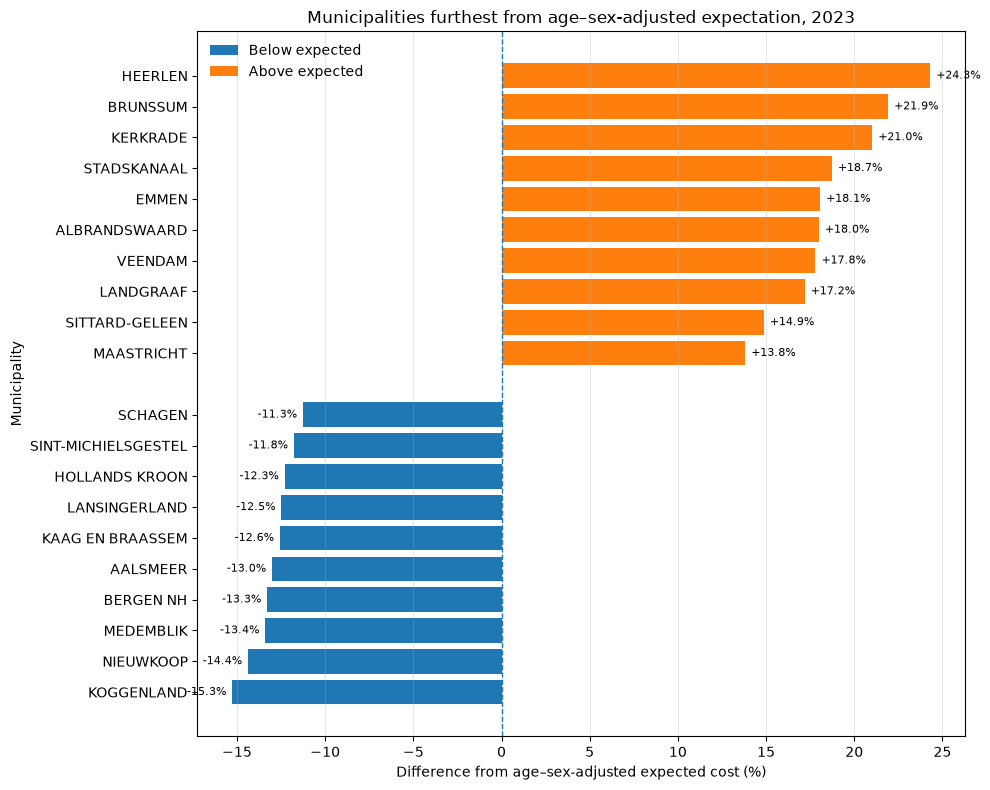

Saved: 01_top_bottom_scr.png


In [3]:
chart_high = (
    highest_not_flagged
    .sort_values("percentage_difference")
)

chart_low = (
    lowest_not_flagged
    .sort_values("percentage_difference")
)

fig, ax = plt.subplots(figsize=(10, 8))

low_positions = np.arange(len(chart_low))
high_positions = np.arange(
    len(chart_low) + 1,
    len(chart_low) + 1 + len(chart_high),
)

ax.barh(
    low_positions,
    chart_low["percentage_difference"],
    label="Below expected",
)

ax.barh(
    high_positions,
    chart_high["percentage_difference"],
    label="Above expected",
)

all_positions = np.concatenate(
    [low_positions, high_positions]
)

all_labels = pd.concat(
    [
        chart_low["gemeentenaam"],
        chart_high["gemeentenaam"],
    ],
    ignore_index=True,
)

ax.set_yticks(all_positions)
ax.set_yticklabels(all_labels)

ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
)

ax.set_xlabel(
    "Difference from age–sex-adjusted expected cost (%)"
)
ax.set_ylabel("Municipality")
ax.set_title(
    "Municipalities furthest from age–sex-adjusted expectation, 2023"
)
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.3)

for position, value in zip(
    all_positions,
    pd.concat(
        [
            chart_low["percentage_difference"],
            chart_high["percentage_difference"],
        ],
        ignore_index=True,
    ),
):
    horizontal_alignment = (
        "left" if value >= 0 else "right"
    )
    offset = 0.35 if value >= 0 else -0.35

    ax.text(
        value + offset,
        position,
        f"{value:+.1f}%",
        va="center",
        ha=horizontal_alignment,
        fontsize=8,
    )

fig.tight_layout()

figure_path = (
    OUTPUT_FIGURES
    / "01_top_bottom_scr.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path.name)

## 3. Chart 2 — distribution across all municipalities

A distribution view shows whether the headline municipalities are isolated extremes or part of a wider spread.

Because each municipality contributes one SCR regardless of population size, the simple mean of municipal SCR values is not expected to equal exactly 1.00. National actual and expected costs reconcile only when weighted by cost exposure.

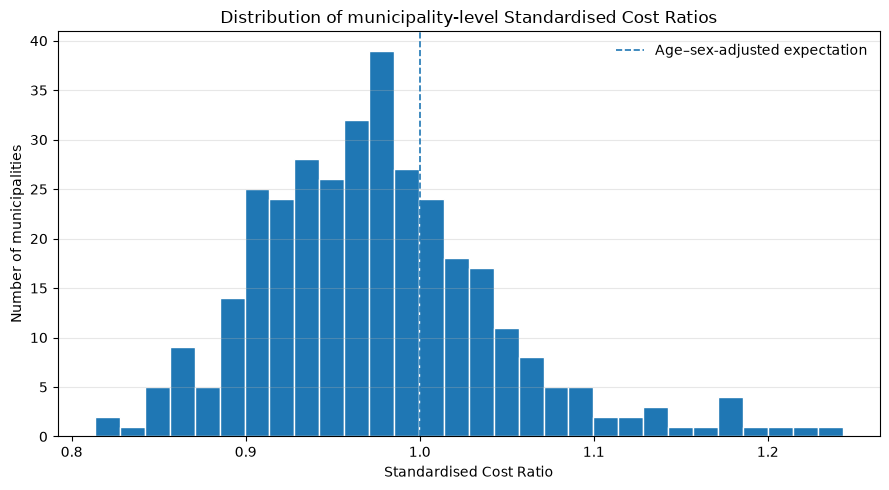

,measure,value
0,Mean municipality SCR,0.975
1,Median municipality SCR,0.971
2,Standard deviation,0.070
3,Minimum SCR,0.813
4,Maximum SCR,1.243
5,Municipalities within ±5% of expected,0.512
6,Municipalities within ±10% of expected,0.845


Saved: 02_scr_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    benchmark["scr"],
    bins=30,
    edgecolor="white",
)

ax.axvline(
    1.0,
    linewidth=1.2,
    linestyle="--",
    label="Age–sex-adjusted expectation",
)

ax.set_xlabel("Standardised Cost Ratio")
ax.set_ylabel("Number of municipalities")
ax.set_title(
    "Distribution of municipality-level Standardised Cost Ratios"
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

figure_path = (
    OUTPUT_FIGURES
    / "02_scr_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

distribution_summary = pd.DataFrame(
    {
        "measure": [
            "Mean municipality SCR",
            "Median municipality SCR",
            "Standard deviation",
            "Minimum SCR",
            "Maximum SCR",
            "Municipalities within ±5% of expected",
            "Municipalities within ±10% of expected",
        ],
        "value": [
            benchmark["scr"].mean(),
            benchmark["scr"].median(),
            benchmark["scr"].std(),
            benchmark["scr"].min(),
            benchmark["scr"].max(),
            benchmark["scr"].between(
                0.95,
                1.05,
            ).mean(),
            benchmark["scr"].between(
                0.90,
                1.10,
            ).mean(),
        ],
    }
)

display(
    distribution_summary.style.format(
        {
            "value": "{:.3f}",
        }
    )
)

print("Saved:", figure_path.name)

## 4. Chart 3 — SCR and municipality size

This chart checks whether large absolute SCR deviations are concentrated among smaller municipalities.

The size flag remains a **descriptive caution heuristic**, not a confidence interval. A formal inferential analysis would require a statistical model and uncertainty estimates.

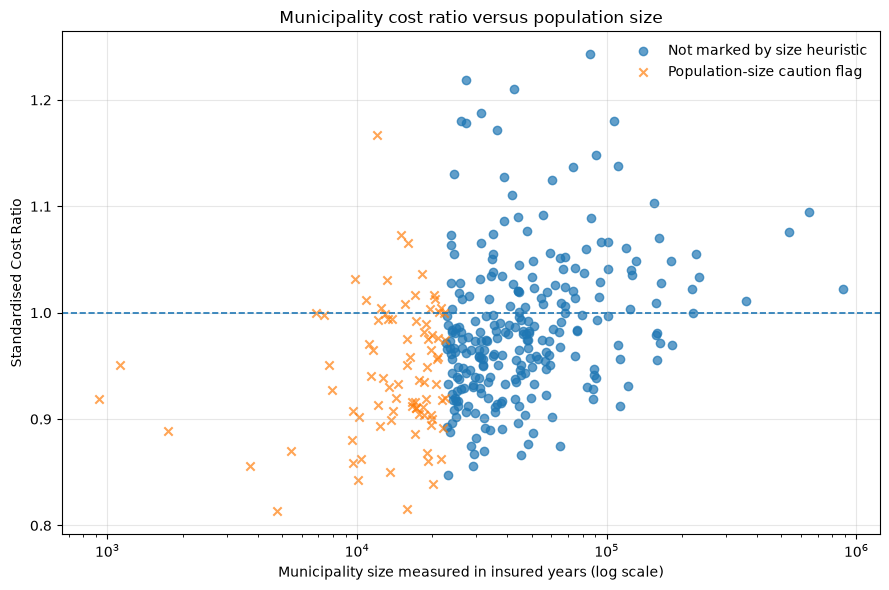

,measure,value
0,Pearson association,-0.088
1,Spearman rank association,-0.168


Saved: 03_scr_vs_population_size.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

not_flagged = benchmark.loc[
    ~benchmark["small_population_caution_flag"]
]

flagged = benchmark.loc[
    benchmark["small_population_caution_flag"]
]

ax.scatter(
    not_flagged["insured_years"],
    not_flagged["scr"],
    alpha=0.70,
    label="Not marked by size heuristic",
)

ax.scatter(
    flagged["insured_years"],
    flagged["scr"],
    alpha=0.70,
    marker="x",
    label="Population-size caution flag",
)

ax.axhline(
    1.0,
    linewidth=1.2,
    linestyle="--",
)

ax.set_xscale("log")
ax.set_xlabel(
    "Municipality size measured in insured years (log scale)"
)
ax.set_ylabel("Standardised Cost Ratio")
ax.set_title(
    "Municipality cost ratio versus population size"
)
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()

figure_path = (
    OUTPUT_FIGURES
    / "03_scr_vs_population_size.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

absolute_deviation = (
    benchmark["scr"]
    .sub(1)
    .abs()
)

size_association_summary = pd.DataFrame(
    {
        "measure": [
            "Pearson association",
            "Spearman rank association",
        ],
        "value": [
            benchmark["insured_years"].corr(
                absolute_deviation
            ),
            benchmark["insured_years"]
            .rank()
            .corr(
                absolute_deviation.rank()
            ),
        ],
    }
)

display(
    size_association_summary.style.format(
        {"value": "{:.3f}"}
    )
)

print("Saved:", figure_path.name)

## 5. Chart 4 — category-level patterns in six spotlight municipalities

This dot plot compares all 11 care-category ratios for the three highest and three lowest non-flagged municipalities.

A category ratio answers a **relative** question. The category euro gap answers an **absolute** question. The two should not be treated as interchangeable.

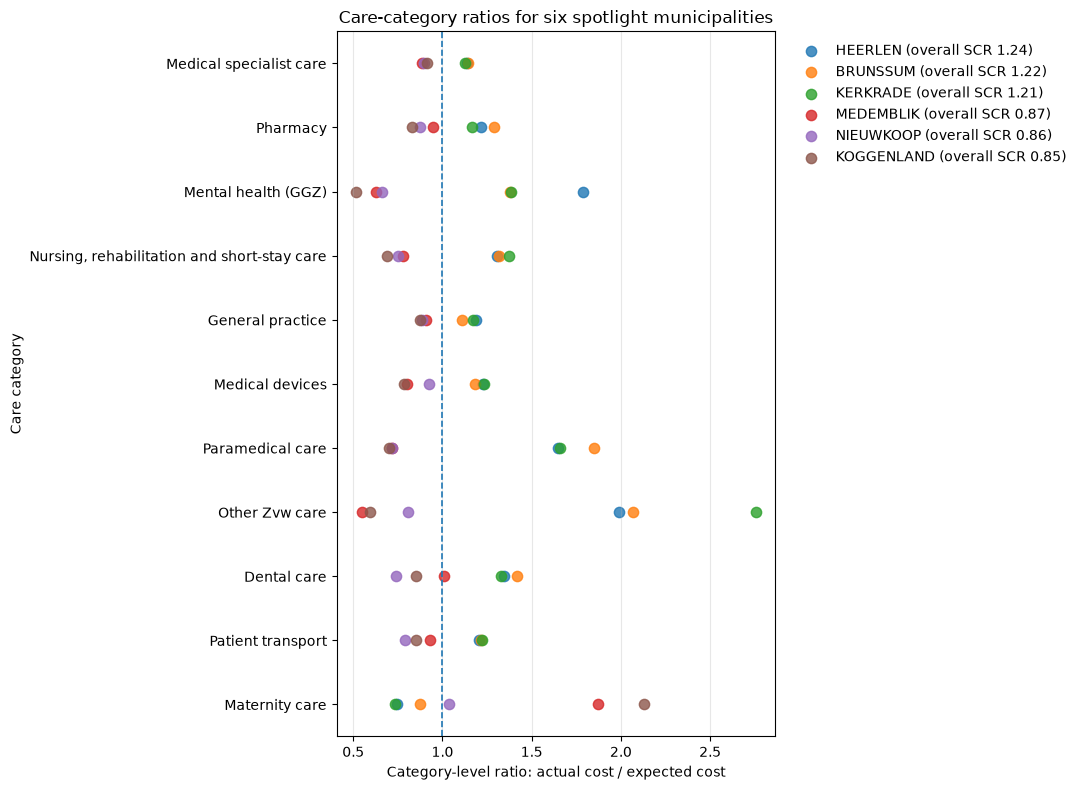

Saved: 04_category_breakdown_outliers.png


In [6]:
spotlight_order = (
    category_spotlight[
        [
            "gemeentenaam",
            "municipality_scr",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "municipality_scr",
        ascending=False,
    )["gemeentenaam"]
    .tolist()
)

care_category_order = (
    category_spotlight
    .groupby(
        "care_category",
        observed=True,
    )["actual_cost"]
    .sum()
    .sort_values()
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 8))

for municipality in spotlight_order:
    municipality_data = (
        category_spotlight.loc[
            category_spotlight[
                "gemeentenaam"
            ]
            == municipality
        ]
        .set_index("care_category")
        .reindex(care_category_order)
        .reset_index()
    )

    municipality_scr = (
        municipality_data[
            "municipality_scr"
        ].iloc[0]
    )

    ax.scatter(
        municipality_data["ratio"],
        municipality_data["care_category"],
        s=55,
        alpha=0.80,
        label=(
            f"{municipality} "
            f"(overall SCR {municipality_scr:.2f})"
        ),
    )

ax.axvline(
    1.0,
    linewidth=1.2,
    linestyle="--",
)

ax.set_xlabel(
    "Category-level ratio: actual cost / expected cost"
)
ax.set_ylabel("Care category")
ax.set_title(
    "Care-category ratios for six spotlight municipalities"
)
ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

figure_path = (
    OUTPUT_FIGURES
    / "04_category_breakdown_outliers.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path.name)

## 6. Relative versus absolute category drivers

For each spotlight municipality, the next table identifies:

- the category with the highest relative ratio
- the category with the largest absolute euro contribution to the municipality gap

For municipalities below expectation, the absolute driver is the category with the most negative euro gap.

In [7]:
driver_rows = []

for municipality in spotlight_order:
    municipality_data = (
        category_spotlight.loc[
            category_spotlight[
                "gemeentenaam"
            ]
            == municipality
        ]
        .copy()
    )

    municipality_scr = (
        municipality_data[
            "municipality_scr"
        ].iloc[0]
    )

    highest_relative_row = (
        municipality_data.loc[
            municipality_data["ratio"].idxmax()
        ]
    )

    if municipality_scr >= 1:
        largest_absolute_row = (
            municipality_data.loc[
                municipality_data["euro_gap"].idxmax()
            ]
        )
    else:
        largest_absolute_row = (
            municipality_data.loc[
                municipality_data["euro_gap"].idxmin()
            ]
        )

    driver_rows.append(
        {
            "municipality": municipality,
            "municipality_scr": municipality_scr,
            "highest_relative_ratio_category": (
                highest_relative_row[
                    "care_category"
                ]
            ),
            "highest_relative_ratio": (
                highest_relative_row["ratio"]
            ),
            "largest_absolute_gap_category": (
                largest_absolute_row[
                    "care_category"
                ]
            ),
            "largest_absolute_gap_eur": (
                largest_absolute_row[
                    "euro_gap"
                ]
            ),
        }
    )

spotlight_driver_summary = pd.DataFrame(
    driver_rows
)

display(
    spotlight_driver_summary.style.format(
        {
            "municipality_scr": "{:.3f}",
            "highest_relative_ratio": "{:.3f}",
            "largest_absolute_gap_eur": "€{:,.0f}",
        }
    )
)

,municipality,municipality_scr,highest_relative_ratio_category,highest_relative_ratio,largest_absolute_gap_category,largest_absolute_gap_eur
0,HEERLEN,1.243,Other Zvw care,1.991,Medical specialist care,"€21,055,747"
1,BRUNSSUM,1.219,Other Zvw care,2.067,Medical specialist care,"€7,196,248"
2,KERKRADE,1.210,Other Zvw care,2.754,Medical specialist care,"€9,827,439"
3,MEDEMBLIK,0.866,Maternity care,1.873,Medical specialist care,"€-9,107,375"
4,NIEUWKOOP,0.856,Maternity care,1.034,Medical specialist care,"€-5,171,813"
5,KOGGENLAND,0.847,Maternity care,2.130,Medical specialist care,"€-3,436,238"


## 7. Interview-ready headline findings

The summary below is deliberately cautious. It describes observed patterns and avoids interpreting them as evidence of healthcare inefficiency or quality differences.

In [8]:
highest_all = (
    benchmark
    .nlargest(1, "scr")
    .iloc[0]
)

lowest_all = (
    benchmark
    .nsmallest(1, "scr")
    .iloc[0]
)

highest_not_flagged_row = (
    benchmark_not_flagged
    .nlargest(1, "scr")
    .iloc[0]
)

lowest_not_flagged_row = (
    benchmark_not_flagged
    .nsmallest(1, "scr")
    .iloc[0]
)

largest_positive_euro_gap = (
    benchmark
    .nlargest(1, "euro_gap")
    .iloc[0]
)

largest_negative_euro_gap = (
    benchmark
    .nsmallest(1, "euro_gap")
    .iloc[0]
)

headline_findings = pd.DataFrame(
    {
        "finding": [
            "Highest SCR across all municipalities",
            "Lowest SCR across all municipalities",
            "Highest SCR not marked by size heuristic",
            "Lowest SCR not marked by size heuristic",
            "Largest positive absolute euro gap",
            "Largest negative absolute euro gap",
            "Share within ±5% of expected",
            "Share within ±10% of expected",
        ],
        "municipality_or_value": [
            highest_all["gemeentenaam"],
            lowest_all["gemeentenaam"],
            highest_not_flagged_row["gemeentenaam"],
            lowest_not_flagged_row["gemeentenaam"],
            largest_positive_euro_gap["gemeentenaam"],
            largest_negative_euro_gap["gemeentenaam"],
            (
                f"{benchmark['scr'].between(0.95, 1.05).mean() * 100:.1f}%"
            ),
            (
                f"{benchmark['scr'].between(0.90, 1.10).mean() * 100:.1f}%"
            ),
        ],
        "supporting_value": [
            f"SCR {highest_all['scr']:.3f}",
            f"SCR {lowest_all['scr']:.3f}",
            f"SCR {highest_not_flagged_row['scr']:.3f}",
            f"SCR {lowest_not_flagged_row['scr']:.3f}",
            f"€{largest_positive_euro_gap['euro_gap']:,.0f}",
            f"€{largest_negative_euro_gap['euro_gap']:,.0f}",
            "",
            "",
        ],
    }
)

display(headline_findings)

print(
    "Interview framing:\n"
    "After adjusting for age and sex, municipality-level healthcare "
    "costs still show meaningful variation. The strongest higher-cost "
    "signals are concentrated in several municipalities in South Limburg, "
    "while the lower end is more sensitive to the population-size heuristic. "
    "The category analysis also shows why relative ratios and absolute euro "
    "gaps need to be discussed separately. These are signals for further "
    "investigation, not conclusions about efficiency or quality."
)

,finding,municipality_or_value,supporting_value
0,Highest SCR across all municipalities,HEERLEN,SCR 1.243
1,Lowest SCR across all municipalities,TERSCHELLING,SCR 0.813
2,Highest SCR not marked by size heuristic,HEERLEN,SCR 1.243
3,Lowest SCR not marked by size heuristic,KOGGENLAND,SCR 0.847
4,Largest positive absolute euro gap,ROTTERDAM,"€177,900,892"
5,Largest negative absolute euro gap,WESTLAND,"€-31,175,075"
6,Share within ±5% of expected,51.2%,
7,Share within ±10% of expected,84.5%,


Interview framing:
After adjusting for age and sex, municipality-level healthcare costs still show meaningful variation. The strongest higher-cost signals are concentrated in several municipalities in South Limburg, while the lower end is more sensitive to the population-size heuristic. The category analysis also shows why relative ratios and absolute euro gaps need to be discussed separately. These are signals for further investigation, not conclusions about efficiency or quality.


## 8. Save summary tables

The final tables support the README, findings report, and Streamlit app.

In [9]:
summary_outputs = {
    "visualization_headline_table.csv": headline_table,
    "distribution_summary.csv": distribution_summary,
    "size_association_summary.csv": size_association_summary,
    "spotlight_category_drivers.csv": spotlight_driver_summary,
    "headline_findings.csv": headline_findings,
}

for filename, output_df in summary_outputs.items():
    output_path = OUTPUT_TABLES / filename
    output_df.to_csv(
        output_path,
        index=False,
    )
    print("Saved:", filename)

Saved: visualization_headline_table.csv
Saved: distribution_summary.csv
Saved: size_association_summary.csv
Saved: spotlight_category_drivers.csv
Saved: headline_findings.csv


## Final interpretation

The age–sex adjustment reduces one important source of unfair comparison, but meaningful municipality-level differences remain.

The strongest conclusions supported by this project are:

1. **Age and sex matter for fair comparison.** Raw municipal healthcare expenditure should not be interpreted without considering population structure.
2. **Relative and absolute differences answer different questions.** SCR identifies proportional deviation, while the euro gap shows potential financial scale.
3. **Population size affects interpretation.** The lower end of the ranking changes substantially when the simple size heuristic is applied.
4. **Category-level drivers differ by municipality.** The category with the highest ratio is not always the category with the largest euro contribution.
5. **The findings are descriptive.** They identify areas for investigation but do not demonstrate inappropriate care, inefficiency, or quality differences.

## Limitations

- The data is aggregated, creating a risk of ecological interpretation.
- Adjustment covers age and sex only.
- Morbidity, deprivation, urbanisation, provider supply, coding behaviour, and patient preferences are not included.
- The analysis covers one year only.
- The population-size flag is a heuristic, not a confidence interval.
- No formal spatial model or statistical significance test is used.
- Municipality-level results cannot be attributed to individual hospitals or providers.

A stronger future extension would combine multiple years, richer case-mix variables, uncertainty intervals, and spatial or provider-level data.